In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv("d://Mining Sector//files//mining_company_data.csv")
df["HireDate"]  = pd.to_datetime(df["HireDate"],  errors="coerce")
df["ShiftDate"] = pd.to_datetime(df["ShiftDate"], errors="coerce")
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})

In [3]:
df_dated = df[df["OreExtracted"] > 0].dropna(subset=["ShiftDate"]).copy()
df_dated["MonthYear"] = df_dated["ShiftDate"].dt.to_period("M")
monthly_ore = df_dated.groupby("MonthYear")["OreExtracted"].sum().sort_values(ascending=False)
print(f"Peak ore extraction month: {monthly_ore.idxmax()} ({monthly_ore.max():,.2f} units)")

Peak ore extraction month: 2018-01 (14,097.96 units)


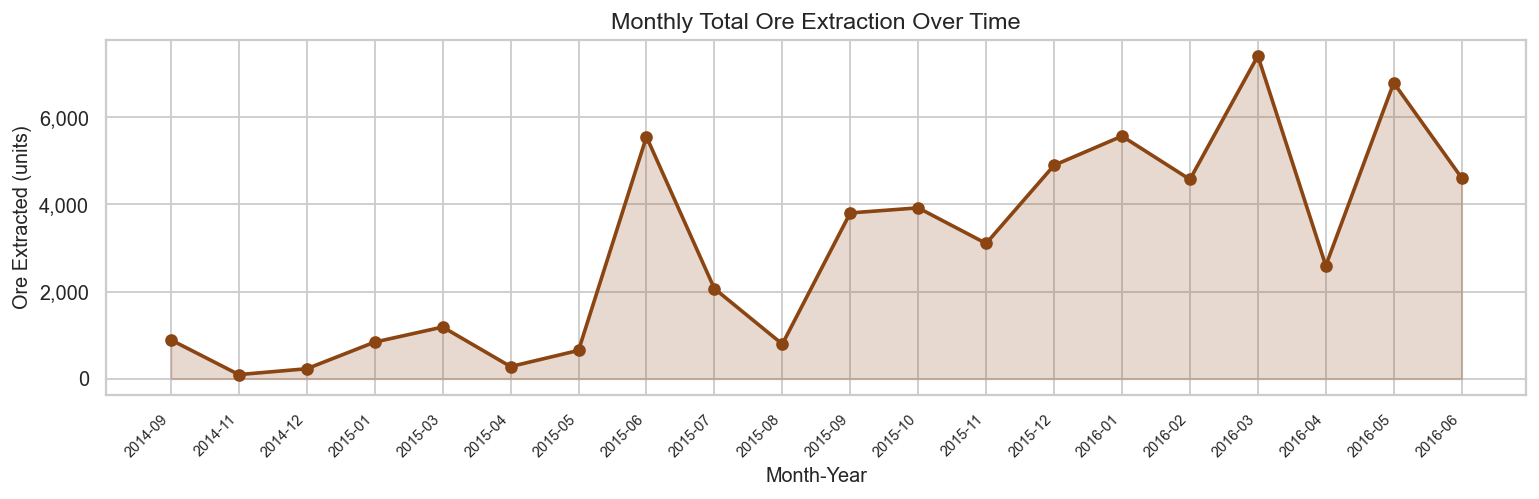

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
monthly_ore_sorted = df_dated.groupby("MonthYear")["OreExtracted"].sum().sort_index().head(20)
ax.plot(monthly_ore_sorted.index.astype(str), monthly_ore_sorted.values,
        marker="o", linewidth=2, color="#8B4513")
ax.fill_between(monthly_ore_sorted.index.astype(str), monthly_ore_sorted.values, alpha=0.2, color="#8B4513")
ax.set_title("Monthly Total Ore Extraction Over Time")
ax.set_xlabel("Month-Year")
ax.set_ylabel("Ore Extracted (units)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()